#Mounting Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd /content/drive/MyDrive/33project/02.자율주행/05.DRAEM/DRAEM-Tensorflow


/content/drive/MyDrive/33project/02.자율주행/05.DRAEM/DRAEM-Tensorflow


#Installing Libraries

In [ ]:
!pip install --upgrade --no-cache-dir gdown
!pip install tensorflow_addons

  Attempting uninstall: gdown
    Found existing installation: gdown 5.2.2
    Uninstalling gdown-5.2.2:
      Successfully uninstalled gdown-5.2.2
ERROR: Could not find a version that satisfies the requirement tensorflow_addons (from versions: none)
ERROR: No matching distribution found for tensorflow_addons


#Importing Libraries

In [ ]:
from dataloader import MVTecDRAEMTestDataset,MVTecDRAEMTrainDataset
import os
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from tensorflow.keras.layers import *
from keras.layers import Input
from tensorflow.keras.models import Model
from keras.layers.pooling.max_pooling2d import MaxPool2D
from keras.layers.core.activation import Activation
from keras.layers.normalization.batch_normalization_v1 import BatchNormalization
from numpy.core.shape_base import block
from keras.layers.convolutional.conv2d_transpose import Conv2D
from loss import FocalLoss
import matplotlib.pyplot as plt
import numpy as np
import tensorflow_addons as tfa


#Defining Variables

In [ ]:
dataset='./datasets'
model='./checkpoints'
lr= 0.0001
epochs=500
data_path='./datasets/mvtec/'
anomaly_source_path='./datasets/dtd/images/'
checkpoint_path='./checkpoints/'
load_epoch=100
object_name='carpet'
object_list=['bottle','carpet']



#Defining Model

In [ ]:



def DiscriminativeSubNetwork(input_shape):
  # Initialize model
  base_channels = 64
  kernel_size = 3
  inputs = Input(shape=input_shape)
  #Encoder Block
  # block 1
  block_1 = Conv2D(filters=base_channels, kernel_size = kernel_size, input_shape=input_shape[1:],padding='same')(inputs)
  block_1 = BatchNormalization()(block_1)
  block_1 = Activation('relu')(block_1)
  block_1 = Conv2D(filters=base_channels, kernel_size = kernel_size, padding='same')(block_1)
  block_1 = BatchNormalization()(block_1)
  block_1 = Activation('relu')(block_1)
  block_1_mp = MaxPool2D(pool_size=(2, 2))(block_1)
  #block_2
  block_2 = Conv2D(filters=base_channels*2, kernel_size = kernel_size, padding='same')(block_1_mp)
  block_2 = BatchNormalization()(block_2)
  block_2 = Activation('relu')(block_2)
  block_2 = Conv2D(filters=base_channels*2, kernel_size = kernel_size, padding='same')(block_2)
  block_2 = BatchNormalization()(block_2)
  block_2 = Activation('relu')(block_2)
  block_2_mp = MaxPool2D(pool_size=(2, 2))(block_2)
  #block_3
  block_3 = Conv2D(filters=base_channels*4, kernel_size = kernel_size, padding='same')(block_2_mp)
  block_3 = BatchNormalization()(block_3)
  block_3 = Activation('relu')(block_3)
  block_3 = Conv2D(filters=base_channels*4, kernel_size = kernel_size, padding='same')(block_3)
  block_3 = BatchNormalization()(block_3)
  block_3 = Activation('relu')(block_3)
  block_3_mp = MaxPool2D(pool_size=(2, 2))(block_3)
  #block_4
  block_4 = Conv2D(filters=base_channels*8, kernel_size = kernel_size, padding='same')(block_3_mp)
  block_4 = BatchNormalization()(block_4)
  block_4 = Activation('relu')(block_4)
  block_4 = Conv2D(filters=base_channels*8, kernel_size = kernel_size, padding='same')(block_4)
  block_4 = BatchNormalization()(block_4)
  block_4 = Activation('relu')(block_4)
  block_4_mp = MaxPool2D(pool_size=(2, 2))(block_4)
  # block_5
  block_5 = Conv2D(filters=base_channels*8, kernel_size = kernel_size, padding='same')(block_4_mp)
  block_5 = BatchNormalization()(block_5)
  block_5 = Activation('relu')(block_5)
  block_5 = Conv2D(filters=base_channels*8, kernel_size = kernel_size, padding='same')(block_5)
  block_5 = BatchNormalization()(block_5)
  block_5 = Activation('relu')(block_5)
  block_5_mp = MaxPool2D(pool_size=(2, 2))(block_5)
  # block_6
  block_6 = Conv2D(filters=base_channels*8, kernel_size = kernel_size, padding='same')(block_5_mp)
  block_6 = BatchNormalization()(block_6)
  block_6 = Activation('relu')(block_6)
  block_6 = Conv2D(filters=base_channels*8, kernel_size = kernel_size, padding='same')(block_6)
  block_6 = BatchNormalization()(block_6)
  #decoder Block
  block_7 = UpSampling2D(size = 2,)(block_6)
  block_7 = Conv2D(filters=base_channels*8, kernel_size = kernel_size, padding='same')(block_7)
  block_7 = BatchNormalization()(block_7)
  block_7 = Activation('relu')(block_7)
  block_7 = Concatenate(axis=3)([block_7, block_5])
  block_7 = Conv2D(filters=base_channels*8, kernel_size = kernel_size, padding='same')(block_7)
  block_7 = BatchNormalization()(block_7)
  block_7 = Activation('relu')(block_7)
  block_7 = Conv2D(filters=base_channels*8, kernel_size = kernel_size, padding='same')(block_7)
  block_7 = BatchNormalization()(block_7)
  block_7 = Activation('relu')(block_7)
  #block_8
  block_8 = UpSampling2D(size = 2,)(block_7)
  block_8 = Conv2D(filters=base_channels*8, kernel_size = kernel_size, padding='same')(block_8)
  block_8 = BatchNormalization()(block_8)
  block_8 = Activation('relu')(block_8)
  block_8 = Concatenate(axis=3)([block_8, block_4])
  block_8 = Conv2D(filters=base_channels*4, kernel_size = kernel_size, padding='same')(block_8)
  block_8 = BatchNormalization()(block_8)
  block_8 = Activation('relu')(block_8)
  block_8 = Conv2D(filters=base_channels*4, kernel_size = kernel_size, padding='same')(block_8)
  block_8 = BatchNormalization()(block_8)
  block_8 = Activation('relu')(block_8)
  #block_9
  block_9 = UpSampling2D(size = 2,)(block_8)
  block_9 = Conv2D(filters=base_channels*4, kernel_size = kernel_size, padding='same')(block_9)
  block_9 = BatchNormalization()(block_9)
  block_9 = Activation('relu')(block_9)
  block_9 = Concatenate(axis=3)([block_9, block_3])
  block_9 = Conv2D(filters=base_channels*2, kernel_size = kernel_size, padding='same')(block_9)
  block_9 = BatchNormalization()(block_9)
  block_9 = Activation('relu')(block_9)
  block_9 = Conv2D(filters=base_channels*2, kernel_size = kernel_size, padding='same')(block_9)
  block_9 = BatchNormalization()(block_9)
  block_9 = Activation('relu')(block_9)
  #block_10
  block_10 = UpSampling2D(size = 2,)(block_9)
  block_10 = Conv2D(filters=base_channels*2, kernel_size = kernel_size, padding='same')(block_10)
  block_10 = BatchNormalization()(block_10)
  block_10 = Activation('relu')(block_10)
  block_10 = Concatenate(axis=3)([block_10, block_2])
  block_10 = Conv2D(filters=base_channels, kernel_size = kernel_size, padding='same')(block_10)
  block_10 = BatchNormalization()(block_10)
  block_10 = Activation('relu')(block_10)
  block_10 = Conv2D(filters=base_channels, kernel_size = kernel_size, padding='same')(block_10)
  block_10 = BatchNormalization()(block_10)
  block_10 = Activation('relu')(block_10)
  #block_11
  block_11 = UpSampling2D(size = 2,)(block_10)
  block_11 = Conv2D(filters=base_channels, kernel_size = kernel_size, padding='same')(block_11)
  block_11 = BatchNormalization()(block_11)
  block_11 = Activation('relu')(block_11)
  block_11 = Concatenate(axis=3)([block_11, block_1])
  block_11 = Conv2D(filters=base_channels, kernel_size = kernel_size, padding='same')(block_11)
  block_11 = BatchNormalization()(block_11)
  block_11 = Activation('relu')(block_11)
  block_11 = Conv2D(filters=base_channels, kernel_size = kernel_size, padding='same')(block_11)
  block_11 = BatchNormalization()(block_11)
  block_11 = Activation('relu')(block_11)

  #output
  outputs = Conv2D(filters=2, kernel_size = kernel_size, padding='same')(block_11)
  model = Model(inputs=[inputs], outputs=[outputs])
  return model


def ReconstructiveSubNetwork(input_shape):
  # Initialize model
  base_channels = 128
  kernel_size = 3
  inputs = Input(shape=input_shape)
  #Encoder Block
  # block 1
  block_1 = Conv2D(filters=base_channels, kernel_size = kernel_size, input_shape=input_shape,padding='same')(inputs)
  block_1 = BatchNormalization()(block_1)
  block_1 = Activation('relu')(block_1)
  block_1 = Conv2D(filters=base_channels, kernel_size = kernel_size, padding='same')(block_1)
  block_1 = BatchNormalization()(block_1)
  block_1 = Activation('relu')(block_1)
  block_1_mp = MaxPool2D(pool_size=(2, 2))(block_1)
  #block_2
  block_2 = Conv2D(filters=base_channels*2, kernel_size = kernel_size, padding='same')(block_1_mp)
  block_2 = BatchNormalization()(block_2)
  block_2 = Activation('relu')(block_2)
  block_2 = Conv2D(filters=base_channels*2, kernel_size = kernel_size, padding='same')(block_2)
  block_2 = BatchNormalization()(block_2)
  block_2 = Activation('relu')(block_2)
  block_2_mp = MaxPool2D(pool_size=(2, 2))(block_2)
  #block_3
  block_3 = Conv2D(filters=base_channels*4, kernel_size = kernel_size, padding='same')(block_2_mp)
  block_3 = BatchNormalization()(block_3)
  block_3 = Activation('relu')(block_3)
  block_3 = Conv2D(filters=base_channels*4, kernel_size = kernel_size, padding='same')(block_3)
  block_3 = BatchNormalization()(block_3)
  block_3 = Activation('relu')(block_3)
  block_3_mp = MaxPool2D(pool_size=(2, 2))(block_3)
  #block_4
  block_4 = Conv2D(filters=base_channels*8, kernel_size = kernel_size, padding='same')(block_3_mp)
  block_4 = BatchNormalization()(block_4)
  block_4 = Activation('relu')(block_4)
  block_4 = Conv2D(filters=base_channels*8, kernel_size = kernel_size, padding='same')(block_4)
  block_4 = BatchNormalization()(block_4)
  block_4 = Activation('relu')(block_4)
  block_4_mp = MaxPool2D(pool_size=(2, 2))(block_4)
  # block_5
  block_5 = Conv2D(filters=base_channels*8, kernel_size = kernel_size, padding='same')(block_4_mp)
  block_5 = BatchNormalization()(block_5)
  block_5 = Activation('relu')(block_5)
  block_5 = Conv2D(filters=base_channels*8, kernel_size = kernel_size, padding='same')(block_5)
  block_5 = BatchNormalization()(block_5)
  block_5 = Activation('relu')(block_5)
  #block_6
  block_6 = UpSampling2D(size = 2,)(block_5)
  block_6 = Conv2D(filters=base_channels*8, kernel_size = kernel_size, padding='same')(block_6)
  block_6 = BatchNormalization()(block_6)
  block_6 = Activation('relu')(block_6)
  block_6 = Conv2D(filters=base_channels*8, kernel_size = kernel_size, padding='same')(block_6)
  block_6 = BatchNormalization()(block_6)
  block_6 = Activation('relu')(block_6)
  block_6 = Conv2D(filters=base_channels*4, kernel_size = kernel_size, padding='same')(block_6)
  block_6 = BatchNormalization()(block_6)
  block_6 = Activation('relu')(block_6)
  #block_7
  block_7 = UpSampling2D(size = 2,)(block_6)
  block_7 = Conv2D(filters=base_channels*4, kernel_size = kernel_size, padding='same')(block_7)
  block_7 = BatchNormalization()(block_7)
  block_7 = Activation('relu')(block_7)
  block_7 = Conv2D(filters=base_channels*4, kernel_size = kernel_size, padding='same')(block_7)
  block_7 = BatchNormalization()(block_7)
  block_7 = Activation('relu')(block_7)
  block_7 = Conv2D(filters=base_channels*2, kernel_size = kernel_size, padding='same')(block_7)
  block_7 = BatchNormalization()(block_7)
  block_7 = Activation('relu')(block_7)
  #block_8
  block_8 = UpSampling2D(size = 2,)(block_7)
  block_8 = Conv2D(filters=base_channels*2, kernel_size = kernel_size, padding='same')(block_8)
  block_8 = BatchNormalization()(block_8)
  block_8 = Activation('relu')(block_8)
  block_8 = Conv2D(filters=base_channels*2, kernel_size = kernel_size, padding='same')(block_8)
  block_8 = BatchNormalization()(block_8)
  block_8 = Activation('relu')(block_8)
  block_8 = Conv2D(filters=base_channels, kernel_size = kernel_size, padding='same')(block_8)
  block_8 = BatchNormalization()(block_8)
  block_8 = Activation('relu')(block_8)
  #block_9
  block_9 = UpSampling2D(size = 2,)(block_8)
  block_9 = Conv2D(filters=base_channels, kernel_size = kernel_size, padding='same')(block_9)
  block_9 = BatchNormalization()(block_9)
  block_9 = Activation('relu')(block_9)
  block_9 = Conv2D(filters=base_channels, kernel_size = kernel_size, padding='same')(block_9)
  block_9 = BatchNormalization()(block_9)
  block_9 = Activation('relu')(block_9)
  block_9 = Conv2D(filters=base_channels, kernel_size = kernel_size, padding='same')(block_9)
  block_9 = BatchNormalization()(block_9)
  block_9 = Activation('relu')(block_9)
  #output
  outputs = Conv2D(filters=3, kernel_size = kernel_size, padding='same')(block_9)
  model = Model(inputs=[inputs], outputs=[outputs])
  return model


# input_shape = (256,256, 3)
# model = ReconstructiveSubNetwork(input_shape)
#
# # model.build(input_shape)
# model.summary()


#Downloading Dataset



In [ ]:
import os
if os.path.exists(dataset) is False:
  print("Downloading Dataset")


  !mkdir datasets
  !wget https://www.robots.ox.ac.uk/~vgg/data/dtd/download/dtd-r1.0.1.tar.gz
  !tar -xf dtd-r1.0.1.tar.gz -C datasets
  !rm dtd-r1.0.1.tar.gz

  os.makedirs('datasets/mvtec')
  # # Download MVTec anomaly detection dataset
  !wget https://www.mydrive.ch/shares/38536/3830184030e49fe74747669442f0f282/download/420938113-1629952094/mvtec_anomaly_detection.tar.xz
  !tar -xf mvtec_anomaly_detection.tar.xz -C datasets/mvtec
  !rm mvtec_anomaly_detection.tar.xz

else:
  print('Dataset already Downloaded')

Dataset already Downloaded


#Downloading PreTrained_Model

In [ ]:
if os.path.exists(model) is False:
  print("Downloading PreTrained Model")


  !mkdir checkpoints
  !gdown https://drive.google.com/uc?id=1jP52vmQCJ27jfHNieZD3Bc56vm0Gb9wc
  !unzip models.zip -d checkpoints


else:
  print('PreTrained Model Already Downloaded')

PreTrained Model Already Downloaded


#Training Script

In [ ]:
model = ReconstructiveSubNetwork((256,256,3))
model_seg = DiscriminativeSubNetwork((256,256,6))

mkdir: cannot create directory ‘checkpoints’: File exists


In [ ]:
load_epoch=100   #Update if You have trained any futher fow now models are trained till 100epochs

#Training Reconstrucrion Model

In [ ]:

dataset = MVTecDRAEMTrainDataset(data_path + object_name + "/train/good/", anomaly_source_path, resize_shape=[256, 256])
add=0
# Set up optimizers
optimizer = tf.optimizers.Adam(learning_rate=lr)
#Loading Checkpoint
if os.path.exists(checkpoint_path+f'model_{object_name}_weights_{load_epoch}.h5'):
  model.load_weights(checkpoint_path+f'model_{object_name}_weights_{load_epoch}.h5')
  print(f'Checkpoint {load_epoch} loaded')
  add=load_epoch
# Training loop
for epoch in range(epochs):
    # Get next batch of data
    for i_batch, sample_batched in enumerate(dataset):
      if i_batch ==10:
        break
      aug_image = sample_batched["augmented_image"]
      anomaly_mask = sample_batched["anomaly_mask"]

      # Preprocess data
      anomaly_mask = np.expand_dims(anomaly_mask, axis=0)
      aug_image = np.expand_dims(aug_image, axis=0)
      gray_batch = sample_batched['image']
      gray_batch = np.expand_dims(gray_batch, axis=0)
      # Run models and calculate losses
      with tf.GradientTape() as tape:
        with tf.device('/GPU:0'):
          gray_rec = model(aug_image)
          image=gray_rec.numpy()
          plt.imshow(image[0])
          plt.show()
          plt.imshow(aug_image[0])
          plt.show()
          loss_mse=tf.keras.losses.MeanSquaredError()
          loss_m=loss_mse(gray_batch,gray_rec)

          ssim = tf.image.ssim(gray_batch,gray_rec, max_val=255, filter_size=11,
                            filter_sigma=1.5, k1=0.01, k2=0.03)
          ssim_loss = (1 - ssim)
          loss = ssim_loss+loss_m


      # Calculate gradients and optimize model
      gradients = tape.gradient(loss, model.trainable_variables)
      optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        # Print loss values at the end of each epoch
      print('Epoch {}: loss = {}'.format(epoch+1, loss))
    if (epoch % 10)==0:
    # Save trained models
      model.save_weights(checkpoint_path+f'model_{object_name}_weights_{epoch+add}.h5')

#Training Discrimination Model

In [ ]:
model = ReconstructiveSubNetwork((256,256,3))
model_seg = DiscriminativeSubNetwork((256,256,6))

In [ ]:


dataset = MVTecDRAEMTrainDataset(data_path + object_name + "/train/good/", anomaly_source_path, resize_shape=[256, 256])


# Set up optimizers
optimizer = tf.optimizers.Adam(learning_rate=lr)

# Set up loss functions

loss_fn = tfa.losses.SigmoidFocalCrossEntropy()

#Loading Reconstruction Model
model.load_weights(checkpoint_path+f'model_{object_name}_weights_{load_epoch}.h5')
print('Model Loaded')
add=0
# Loading Model
if os.path.exists(checkpoint_path+f'model_seg_{object_name}_weights_{load_epoch}.h5'):
  model_seg.load_weights(checkpoint_path+f'model_seg_{object_name}_weights_{load_epoch}.h5')
  print(f'Checkpoint {load_epoch} loaded')
  add=load_epoch

for epoch in range(epochs):
    # Get next batch of data
    for i_batch, sample_batched in enumerate(dataset):
      if i_batch ==len(dataset):
        break
      aug_image = sample_batched["augmented_image"]
      anomaly_mask = sample_batched["anomaly_mask"]

      # Preprocess data
      anomaly_mask = np.expand_dims(anomaly_mask, axis=0)
      aug_image = np.expand_dims(aug_image, axis=0)
      gray_batch = sample_batched['image']
      gray_batch = np.expand_dims(gray_batch, axis=0)
      # Run models and calculate losses
      with tf.GradientTape() as tape:
        with tf.device('/GPU:0'):
          gray_rec = model(aug_image)
          image=gray_rec.numpy()
          plt.imshow(image[0])
          plt.show()
          joined_in = tf.concat([gray_rec, aug_image], axis=3)
          out_mask = model_seg(joined_in)
          plt.imshow(out_mask[0][:,:,0])
          plt.show()
          plt.imshow(anomaly_mask[0][:,:,0])
          plt.show()
          loss_fl = loss_fn(anomaly_mask,out_mask)
          loss_fl = tf.reduce_mean(loss_fl)

          loss = loss_fl


      # Calculate gradients and optimize model

      gradients = tape.gradient(loss,model_seg.trainable_variables)
      optimizer.apply_gradients(zip(gradients,model_seg.trainable_variables))

        # Print loss values at the end of each epoch
      print('Epoch {}: loss = {}'.format(epoch+1, loss))
    if (epoch % 10)==0:
    # Save trained models
      model_seg.save_weights(checkpoint_path+f'model_seg_{object_name}_weights_{epoch+add}.h5')

#Inference Script

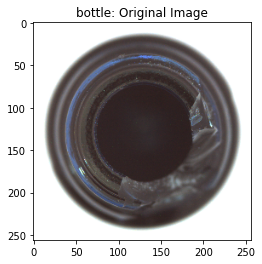

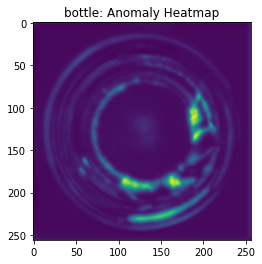

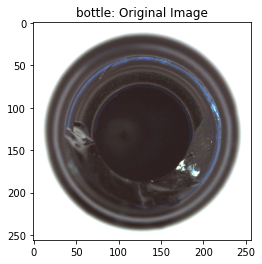

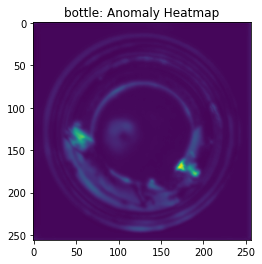

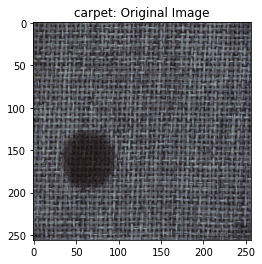

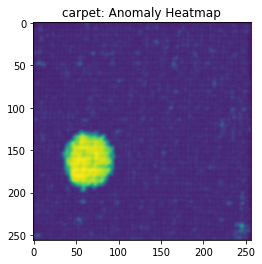

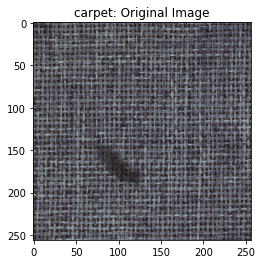

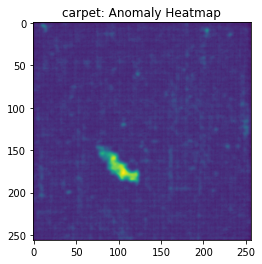

In [ ]:
def predict(object_name:str, load_epoch:int, checkpoint_path:str, data_path:str, resize_shape):
    model = ReconstructiveSubNetwork((256,256,3))
    model_seg = DiscriminativeSubNetwork((256,256,6))
    model.load_weights(checkpoint_path+f'model_{object_name}_weights_{load_epoch}.h5')
    model_seg.load_weights(checkpoint_path+f'model_seg_{object_name}_weights_{load_epoch}.h5')
    dataset = MVTecDRAEMTestDataset(data_path + object_name + "/test/", resize_shape=resize_shape)

    for i_batch, sample_batched in enumerate(dataset):
        if i_batch == 2:
            break
        gray_batch = sample_batched["image"]
        gray_batch = np.expand_dims(gray_batch, axis=0)
        plt.imshow(gray_batch[0], cmap='gray')
        plt.title(f'{object_name}: Original Image')
        plt.show()
        gray_rec = model(gray_batch)
        joined_in = tf.concat([gray_rec, gray_batch], axis=3)
        out_mask = model_seg(joined_in)
        plt.imshow(out_mask[0][:,:,0])
        plt.title(f'{object_name}: Anomaly Heatmap')
        plt.show()

# Function call
for i in object_list:
  predict(object_name=i, load_epoch=load_epoch, checkpoint_path=checkpoint_path, data_path=data_path, resize_shape=[256,256])
